COLAB PRO

In [1]:
from psutil import virtual_memory
ram_gb = virtual_memory().total / 1e9
print('Your runtime has {:.1f} gigabytes of available RAM\n'.format(ram_gb))

if ram_gb < 20:
  print('Not using a high-RAM runtime')
else:
  print('You are using a high-RAM runtime!')

Your runtime has 13.6 gigabytes of available RAM

Not using a high-RAM runtime


In [2]:

!pip uninstall -y transformers
!pip install transformers==4.41.2

Found existing installation: transformers 5.0.0
Uninstalling transformers-5.0.0:
  Successfully uninstalled transformers-5.0.0
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.8/43.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 111.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 122.5 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.7.1
    Uninstalling huggingface_hub-1.7.1:
      Successfully uninstalled huggingface_hub-1.7.1
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2


Bert + hasoc2019

In [4]:
import pandas as pd
df = pd.read_csv('hasoc2019.csv',encoding='utf8')
df

,text_id,text,hate
0,hasoc_en_4939,A gangster sets out to fulfill his father’s dr...,1
1,hasoc_en_177,That’s not white supremacy though is it. That ...,1
2,hasoc_en_1061,Sit his ass down! Tape his fingers and duct-t...,1
3,hasoc_en_663,“It is absolutely right that the government do...,0
4,hasoc_en_1858,Timewear Analogue White Round Dial Leather Str...,0
...,...,...,...
7000,hasoc_en_5639,@MichaelVaughan Why you are not opening your w...,1
7001,hasoc_en_2328,ICC behaving like ECI #DhoniKeepsTheGlove,0
7002,hasoc_en_1335,Don't cancel matches due to Rain. Just Give t...,0
7003,hasoc_en_4032,@Acosta @ReliableSources @brianstelter @CBSSun...,1


In [5]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib
import matplotlib.pyplot as plt
import nltk
import seaborn as sns
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
%matplotlib inline


# Load Huggingface transformers
from transformers import TFBertModel,  BertConfig, BertTokenizerFast, TFAutoModel

# Then what you need from tensorflow.keras
from tensorflow.keras.layers import Input, Dropout, Dense, GlobalAveragePooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.initializers import TruncatedNormal
from tensorflow.keras.losses import CategoricalCrossentropy
from tensorflow.keras.metrics import CategoricalAccuracy
from tensorflow.keras.utils import to_categorical


pd.set_option('display.max_colwidth', 100)

In [6]:
import re,string,unicodedata
from collections import Counter
import string

import warnings
warnings.filterwarnings('ignore')
from nltk.tokenize.toktok import ToktokTokenizer
from nltk.stem import LancasterStemmer,WordNetLemmatizer
from sklearn.linear_model import LogisticRegression,SGDClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from sklearn.model_selection import train_test_split
from string import punctuation
from nltk import pos_tag
from nltk.corpus import wordnet

from sklearn.metrics import accuracy_score, precision_score, recall_score,f1_score
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_val_score
import warnings
from sklearn.pipeline import Pipeline

In [7]:
import pandas as pd
import tensorflow as tf

from transformers import BertTokenizerFast, TFAutoModel
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load dataset
df = pd.read_csv('hasoc2019.csv', encoding='utf8')

# Labels
df_la = pd.get_dummies(df, columns=['hate'])
train_sentences = df["text"].values
list_classes = ['hate_0', 'hate_1']
train_y = df_la[list_classes].values

# Parameters
model_name = 'bert-base-uncased'
max_length = 128

# Tokenizer + BERT
tokenizer = BertTokenizerFast.from_pretrained(model_name)
bert = TFAutoModel.from_pretrained(model_name)

# Inputs
input_ids = Input(shape=(max_length,), dtype=tf.int32, name='input_ids')
attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='attention_mask')

# BERT output
bert_output = Lambda(
    lambda x: bert(x[0], attention_mask=x[1]).last_hidden_state,
    output_shape=(max_length, 768)
)([input_ids, attention_mask])

# CLS token
cls_token = Lambda(
    lambda x: x[:, 0, :],
    output_shape=(768,)
)(bert_output)

# Stronger classifier head
x = Dense(128, activation='relu')(cls_token)
x = Dropout(0.4)(x)

# Output
output = Dense(2, activation='softmax')(x)

# Model
model = Model(inputs=[input_ids, attention_mask], outputs=output)

# Compile
optimizer = Adam(learning_rate=3e-5)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Tokenize
tokens = tokenizer(
    list(train_sentences),
    padding='max_length',
    truncation=True,
    max_length=max_length,
    return_tensors='tf'
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Train
history = model.fit(
    x={
        'input_ids': tokens['input_ids'],
        'attention_mask': tokens['attention_mask']
    },
    y=train_y,
    validation_split=0.1,
    batch_size=16,
    epochs=5,
    callbacks=[early_stop],
    verbose=1
)


model.summary()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

...

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda (Lambda)     │ (None, 128, 768)  │          0 │ input_ids[0][0],  │
│                     │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_1 (Lambda)   │ (None, 768)       │          0 │ lambda[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 128)       │     98,432 │ lambda_1[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128)       │          0 │ dense[0][0]       │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 2)         │        258 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 296,072 (1.13 MB)

 Trainable params: 98,690 (385.51 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 197,382 (771.03 KB)

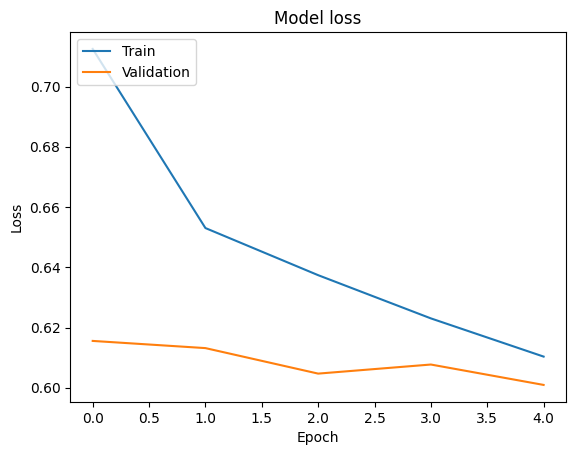

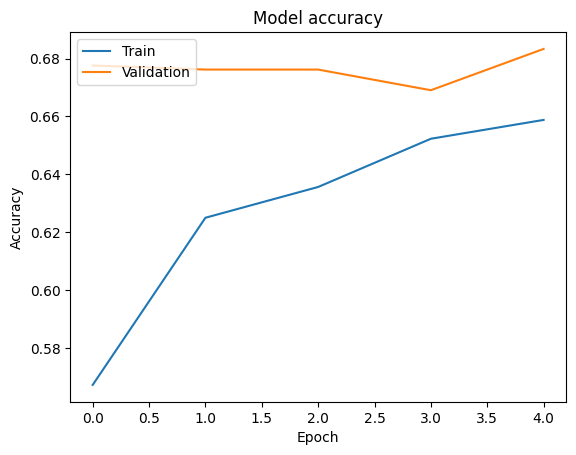

In [8]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Bert + cnn + hasoc2019

In [9]:
import pandas as pd
import tensorflow as tf

from transformers import BertTokenizerFast, TFAutoModel
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda, Conv1D, GlobalMaxPooling1D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

# Load dataset
df = pd.read_csv('hasoc2019.csv', encoding='utf8')

# Labels
df_la = pd.get_dummies(df, columns=['hate'])
train_sentences = df["text"].values
list_classes = ['hate_0', 'hate_1']
train_y = df_la[list_classes].values

# Parameters
model_name = 'bert-base-uncased'
max_length = 128

# Tokenizer + BERT
tokenizer = BertTokenizerFast.from_pretrained(model_name)
bert = TFAutoModel.from_pretrained(model_name)

# Inputs
input_ids = Input(shape=(max_length,), dtype=tf.int32, name='input_ids')
attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='attention_mask')

# Correct BERT output
bert_output = Lambda(
    lambda x: bert(x[0], attention_mask=x[1]).last_hidden_state,
    output_shape=(max_length, 768)
)([input_ids, attention_mask])

# CNN layer
x = Conv1D(128, 3, activation='relu')(bert_output)

# Pooling
x = GlobalMaxPooling1D()(x)

# Dropout
x = Dropout(0.4)(x)

# Dense layer
x = Dense(64, activation='relu')(x)

# Output
output = Dense(2, activation='softmax')(x)

# Model
model = Model(inputs=[input_ids, attention_mask], outputs=output)

# Compile
model.compile(
    optimizer=Adam(learning_rate=2e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Tokenization
tokens = tokenizer(
    list(train_sentences),
    padding='max_length',
    truncation=True,
    max_length=max_length,
    return_tensors='tf'
)

# Train
history = model.fit(
    x={
        'input_ids': tokens['input_ids'],
        'attention_mask': tokens['attention_mask']
    },
    y=train_y,
    validation_split=0.1,
    batch_size=16,
    epochs=5,
    verbose=1
)


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Epoch 1/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 92s 199ms/step - accuracy: 0.5609 - loss: 0.8621 - val_accuracy: 0.6819 - val_loss: 0.6265
Epoch 2/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 60s 153ms/step - accuracy: 0.5985 - loss: 0.7413 - val_accuracy: 0.6833 - val_loss: 0.6098
Epoch 3/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 58s 147ms/step - accuracy: 0.6177 - loss: 0.6875 - val_accuracy: 0.6947 - val_loss: 0.6050
Epoch 4/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 59s 150ms/step - accuracy: 0.6505 - loss: 0.6469 - val_accuracy: 0.7019 - val_loss: 0.5934
Epoch 5/5
394/394 ━━━━━━━━━━━━━━━━━━━━ 59s 150ms/step - accuracy: 0.6553 - loss: 0.6298 - val_accuracy: 0.7019 - val_loss: 0.5908


In [10]:
model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_2 (Lambda)   │ (None, 128, 768)  │          0 │ input_ids[0][0],  │
│                     │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 126, 128)  │    295,040 │ lambda_2[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_max_pooling… │ (None, 128)       │          0 │ conv1d[0][0]      │
│ (GlobalMaxPooling1… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 128)       │          0 │ global_max_pooli… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 64)        │      8,256 │ dropout_1[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 2)         │        130 │ dense_2[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 910,280 (3.47 MB)

 Trainable params: 303,426 (1.16 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 606,854 (2.31 MB)

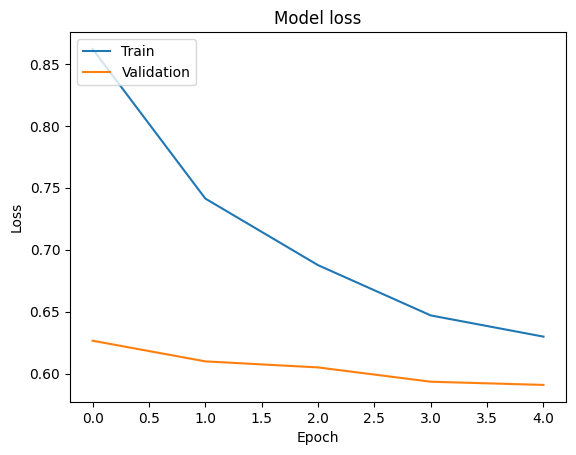

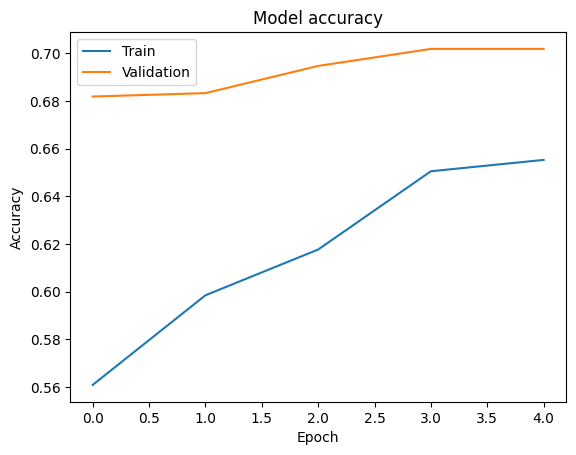

In [11]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Bert + labeled_data

In [12]:
df = pd.read_csv('labeled_data.csv',encoding='utf8')
print(df)

       Unnamed: 0  count  hate_speech  offensive_language  neither  class  \
0               0      3            0                   0        3      2   
1               1      3            0                   3        0      1   
2               2      3            0                   3        0      1   
3               3      3            0                   2        1      1   
4               4      6            0                   6        0      1   
...           ...    ...          ...                 ...      ...    ...   
24778       25291      3            0                   2        1      1   
24779       25292      3            0                   1        2      2   
24780       25294      3            0                   3        0      1   
24781       25295      6            0                   6        0      1   
24782       25296      3            0                   0        3      2   

                                                                           

In [13]:
import pandas as pd
import tensorflow as tf

from transformers import BertTokenizerFast, TFAutoModel, BertConfig
from tensorflow.keras.layers import Input, Dense, Dropout, Lambda
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Load dataset
df = pd.read_csv('labeled_data.csv', encoding='utf8')

# BERT model
model_name = 'bert-base-uncased'
max_length = 128

# Config
config = BertConfig.from_pretrained(model_name)

# Tokenizer + model
tokenizer = BertTokenizerFast.from_pretrained(model_name)
bert = TFAutoModel.from_pretrained(model_name)

# Labels
df_la = pd.get_dummies(df, columns=['class'])

train_sentences = df["tweet"].astype(str).values
list_classes = ['class_0', 'class_1', 'class_2']
train_y = df_la[list_classes].values

# Inputs
input_ids = Input(shape=(max_length,), dtype=tf.int32, name='input_ids')
attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='attention_mask')

# Correct BERT call
bert_output = Lambda(
    lambda x: bert(x[0], attention_mask=x[1]).last_hidden_state,
    output_shape=(max_length, 768)
)([input_ids, attention_mask])

# CLS token
cls_token = Lambda(
    lambda x: x[:, 0, :],
    output_shape=(768,)
)(bert_output)

# Dense head
x = Dense(128, activation='relu')(cls_token)
x = Dropout(0.4)(x)

# Output layer (3 classes)
output = Dense(3, activation='softmax', name='outputs')(x)

# Model
model = Model(inputs=[input_ids, attention_mask], outputs=output)

# Compile
optimizer = Adam(learning_rate=2e-5)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

# Tokenize
tokens = tokenizer(
    list(train_sentences),
    add_special_tokens=True,
    max_length=max_length,
    truncation=True,
    padding='max_length',
    return_tensors='tf'
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Train
history = model.fit(
    x={
        'input_ids': tokens['input_ids'],
        'attention_mask': tokens['attention_mask']
    },
    y=train_y,
    validation_split=0.1,
    batch_size=16,
    epochs=5,
    callbacks=[early_stop],
    verbose=1
)

# Summary
model.summary()

Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Epoch 1/5
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 227s 155ms/step - accuracy: 0.7554 - loss: 0.6716 - val_accuracy: 0.8294 - val_loss: 0.4921
Epoch 2/5
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 205s 147ms/step - accuracy: 0.8046 - loss: 0.5410 - val_accuracy: 0.8447 - val_loss: 0.4502
Epoch 3/5
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 204s 147ms/step - accuracy: 0.8220 - loss: 0.4958 - val_accuracy: 0.8528 - val_loss: 0.4290
Epoch 4/5
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 205s 147ms/step - accuracy: 0.8279 - loss: 0.4798 - val_accuracy: 0.8580 - val_loss: 0.4187
Epoch 5/5
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 205s 147ms/step - accuracy: 0.8336 - loss: 0.4632 - val_accuracy: 0.8588 - val_loss: 0.4090


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_3 (Lambda)   │ (None, 128, 768)  │          0 │ input_ids[0][0],  │
│                     │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_4 (Lambda)   │ (None, 768)       │          0 │ lambda_3[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 128)       │     98,432 │ lambda_4[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 128)       │          0 │ dense_4[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ outputs (Dense)     │ (None, 3)         │        387 │ dropout_2[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 296,459 (1.13 MB)

 Trainable params: 98,819 (386.01 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 197,640 (772.04 KB)

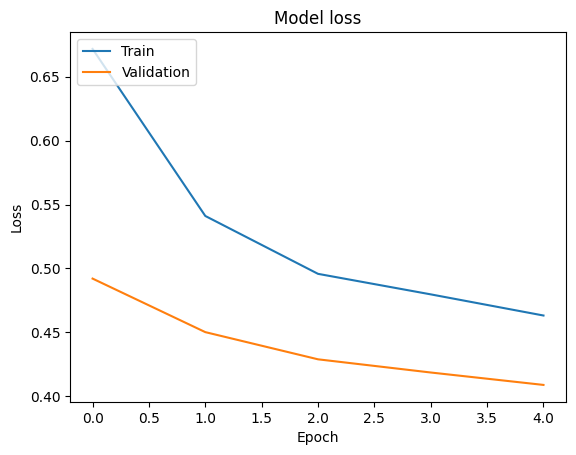

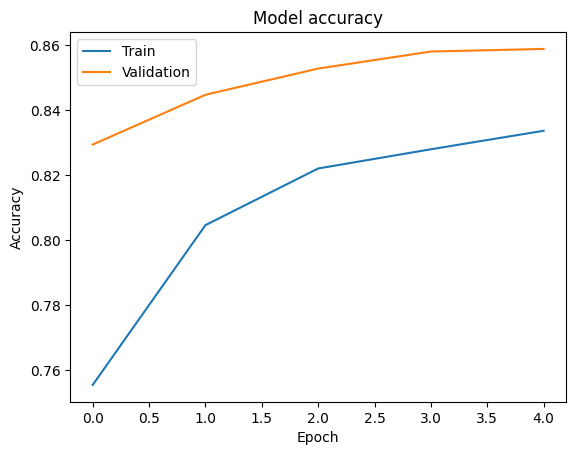

In [14]:
import matplotlib.pyplot as plt

# Plot training & validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

Bert + cnn + labeled_data

In [15]:
import tensorflow as tf
import pandas as pd

from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Input, Dense, Conv1D, MaxPooling1D, GlobalAveragePooling1D, Lambda, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping

from transformers import BertTokenizerFast, TFAutoModel, BertConfig

# Load dataset
df = pd.read_csv('labeled_data.csv', encoding='utf8')

# Basic preprocessing
df['tweet'] = df['tweet'].astype(str).str.lower()

# Model settings
model_name = 'bert-base-uncased'
max_length = 128

# Config + tokenizer + BERT
config = BertConfig.from_pretrained(model_name)
tokenizer = BertTokenizerFast.from_pretrained(model_name)
bert = TFAutoModel.from_pretrained(model_name)

# Inputs
input_ids = Input(shape=(max_length,), dtype=tf.int32, name='input_ids')
attention_mask = Input(shape=(max_length,), dtype=tf.int32, name='attention_mask')

# Correct BERT output
bert_output = Lambda(
    lambda x: bert(x[0], attention_mask=x[1]).last_hidden_state,
    output_shape=(max_length, 768)
)([input_ids, attention_mask])

# CNN layer
x = Conv1D(filters=64, kernel_size=3, activation='relu', padding='same')(bert_output)

# MaxPooling
x = MaxPooling1D(pool_size=2)(x)

# Global pooling
x = GlobalAveragePooling1D()(x)

# Dropout
x = Dropout(0.3)(x)

# Output layer
output = Dense(3, activation='softmax', name='outputs')(x)

# Model
model = Model(inputs=[input_ids, attention_mask], outputs=output)

# Summary
model.summary()

# Tokenization
tokens = tokenizer(
    list(df['tweet'].values),
    add_special_tokens=True,
    max_length=max_length,
    truncation=True,
    padding='max_length',
    return_tensors='tf'
)

# Labels
y = pd.get_dummies(df['class']).values

# Compile
optimizer = Adam(learning_rate=2e-5)

model.compile(
    loss='categorical_crossentropy',
    optimizer=optimizer,
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=2,
    restore_best_weights=True
)

# Train
history = model.fit(
    x={
        'input_ids': tokens['input_ids'],
        'attention_mask': tokens['attention_mask']
    },
    y=y,
    validation_split=0.1,
    batch_size=16,
    epochs=5,
    callbacks=[early_stop],
    verbose=1
)


Some weights of the PyTorch model were not used when initializing the TF 2.0 model TFBertModel: ['cls.seq_relationship.bias', 'cls.predictions.transform.dense.bias', 'cls.predictions.transform.LayerNorm.bias', 'cls.predictions.transform.LayerNorm.weight', 'cls.predictions.bias', 'cls.predictions.transform.dense.weight', 'cls.seq_relationship.weight']
- This IS expected if you are initializing TFBertModel from a PyTorch model trained on another task or with another architecture (e.g. initializing a TFBertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing TFBertModel from a PyTorch model that you expect to be exactly identical (e.g. initializing a TFBertForSequenceClassification model from a BertForSequenceClassification model).
All the weights of TFBertModel were initialized from the PyTorch model.
If your task is similar to the task the model of the checkpoint was trained on, you can already use TFBertModel for predictions w

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_ids           │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention_mask      │ (None, 128)       │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lambda_5 (Lambda)   │ (None, 128, 768)  │          0 │ input_ids[0][0],  │
│                     │                   │            │ attention_mask[0… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d_1 (Conv1D)   │ (None, 128, 64)   │    147,520 │ lambda_5[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling1d       │ (None, 64, 64)    │          0 │ conv1d_1[0][0]    │
│ (MaxPooling1D)      │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 64)        │          0 │ max_pooling1d[0]… │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_3 (Dropout) │ (None, 64)        │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ outputs (Dense)     │ (None, 3)         │        195 │ dropout_3[0][0]   │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 147,715 (577.01 KB)

 Trainable params: 147,715 (577.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/5
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 228s 155ms/step - accuracy: 0.7934 - loss: 0.5694 - val_accuracy: 0.8592 - val_loss: 0.4294
Epoch 2/5
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 208s 149ms/step - accuracy: 0.8343 - loss: 0.4666 - val_accuracy: 0.8628 - val_loss: 0.3954
Epoch 3/5
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 207s 148ms/step - accuracy: 0.8438 - loss: 0.4370 - val_accuracy: 0.8653 - val_loss: 0.3795
Epoch 4/5
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 208s 149ms/step - accuracy: 0.8485 - loss: 0.4222 - val_accuracy: 0.8677 - val_loss: 0.3701
Epoch 5/5
1394/1394 ━━━━━━━━━━━━━━━━━━━━ 208s 149ms/step - accuracy: 0.8529 - loss: 0.4116 - val_accuracy: 0.8717 - val_loss: 0.3621


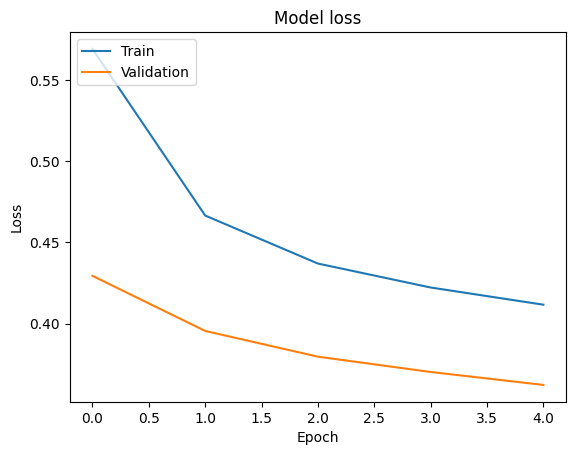

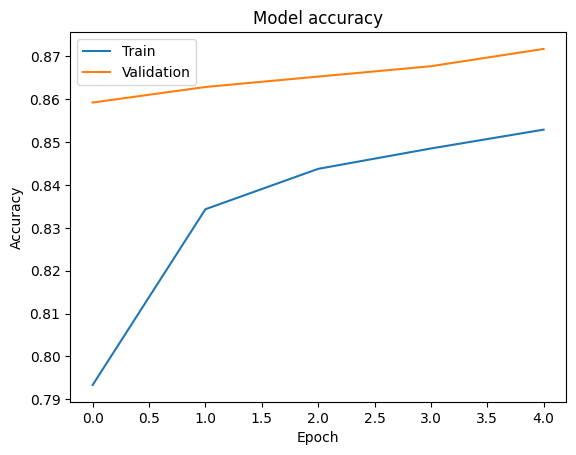

In [16]:
import matplotlib.pyplot as plt
#adadelta optimizer
# Plot training & validation loss
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation accuracy
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()